In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv(r'D:\IngeDan\Valores_Nulos\Ottawa_sin_nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2727 entries, 0 to 2726
Data columns (total 51 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   2727 non-null   int64  
 1   id                                           2727 non-null   float64
 2   last_scraped                                 2727 non-null   str    
 3   source                                       2727 non-null   str    
 4   name                                         2727 non-null   str    
 5   host_id                                      2727 non-null   float64
 6   host_name                                    2727 non-null   str    
 7   hosts_time_as_user_years                     2727 non-null   int64  
 8   hosts_time_as_user_months                    2727 non-null   int64  
 9   hosts_time_as_host_years                     2727 non-null   int64  
 10  hosts_time_

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Unnamed: 0                                     0
id                                             0
last_scraped                                   0
source                                         0
name                                           0
host_id                                        0
host_name                                      0
hosts_time_as_user_years                       0
hosts_time_as_user_months                      0
hosts_time_as_host_years                       0
hosts_time_as_host_months                      0
host_location                                  0
host_is_superhost                              0
host_listings_count                            0
host_identity_verified                         0
neighbourhood_cleansed                         0
latitude                                       0
longitude                                      0
property_type                                  0
room_type                                      0
accommodates        

##Hasta ahi el DataFrame esta bien y limpio

In [5]:
#Realizamos una copia del dataframe para poder modificarla
data2=data.copy()

In [6]:
data2.shape

(2727, 51)

In [7]:
data2.describe()

,Unnamed: 0,id,host_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
count,2727.000000,2.727000e+03,2.727000e+03,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,...,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000,2727.000000
mean,1363.000000,8.653905e+17,3.685369e+15,6.883388,5.769710,4.548588,5.576458,7.214888,45.371287,-75.706381,...,12.574991,4.774048,4.790099,4.871929,4.861551,4.791331,4.704518,1.789850,4.543088,2.448111
std,787.361416,6.115271e+17,7.849806e+16,3.728443,3.658645,3.533786,3.461973,15.601372,0.073714,0.113486,...,21.859875,0.386158,0.378263,0.324596,0.349118,0.301608,0.404070,1.884117,6.464211,5.026869
min,0.000000,2.610650e+05,1.104060e+05,0.000000,0.000000,0.000000,0.000000,1.000000,44.987440,-76.275220,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,681.500000,5.159270e+07,6.094450e+07,4.000000,2.000000,2.000000,2.000000,1.000000,45.323220,-75.747452,...,0.000000,4.780000,4.800000,4.900000,4.890000,4.780000,4.700000,0.350000,1.000000,0.000000
50%,1363.000000,9.940000e+17,1.898480e+08,8.000000,6.000000,4.000000,6.000000,2.000000,45.396020,-75.693360,...,2.000000,4.810000,4.840000,4.920000,4.910000,4.810000,4.740000,1.620000,2.000000,1.000000
75%,2044.500000,1.400000e+18,4.614276e+08,10.000000,9.000000,8.000000,9.000000,5.000000,45.428370,-75.656415,...,17.000000,4.960000,4.960000,5.000000,5.000000,4.940000,4.900000,2.045000,5.000000,2.000000
max,2726.000000,1.710000e+18,1.700000e+18,16.000000,11.000000,14.000000,11.000000,152.000000,45.520850,-75.268360,...,140.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,14.070000,28.000000,28.000000


In [8]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2727 entries, 0 to 2726
Data columns (total 51 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   2727 non-null   int64  
 1   id                                           2727 non-null   float64
 2   last_scraped                                 2727 non-null   str    
 3   source                                       2727 non-null   str    
 4   name                                         2727 non-null   str    
 5   host_id                                      2727 non-null   float64
 6   host_name                                    2727 non-null   str    
 7   hosts_time_as_user_years                     2727 non-null   int64  
 8   hosts_time_as_user_months                    2727 non-null   int64  
 9   hosts_time_as_host_years                     2727 non-null   int64  
 10  hosts_time_

In [9]:
#Creo 2 dataframe para poder procesar los outliers
#Cuantitativos son floats y int
#0,1,5= esos no porque como son series se cancelan
cuantitativas = data2.iloc[:, [7,8,9,10,13,16,17,20,21,22,23,24,27,28,29,30,32,33,34,35,37,38,39,42,43,44,45,46,47,48,49,50]].astype(int)
#Cualitativos serian los str
cualitativas= data2.iloc[ : , [2,3,4,6,11,12,14,15,18,19,25,26,31,36,40,41]]
#cualitativas
cuantitativas

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,14,7,14,7,1,45,-75,4,1,2,...,21,4,4,4,4,4,4,0,1,1
1,15,3,14,6,1,45,-75,4,1,2,...,8,5,5,4,4,5,4,0,1,1
2,14,1,14,1,3,45,-75,1,1,2,...,2,5,5,5,5,4,4,0,1,0
3,14,2,14,2,1,45,-75,6,1,5,...,15,4,4,4,4,4,4,0,1,1
4,13,10,13,10,8,45,-75,4,1,2,...,2,4,4,4,4,4,4,0,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2722,8,10,2,9,1,45,-75,6,3,3,...,0,4,4,4,4,4,4,1,1,1
2723,1,11,1,11,2,45,-75,1,1,1,...,0,4,4,4,4,4,4,1,2,1
2724,2,1,0,0,2,45,-75,2,1,1,...,0,4,4,4,4,4,4,1,2,2
2725,1,11,1,10,1,45,-75,6,2,3,...,0,4,4,4,4,4,4,1,1,1


<Figure size 2000x1500 with 0 Axes>

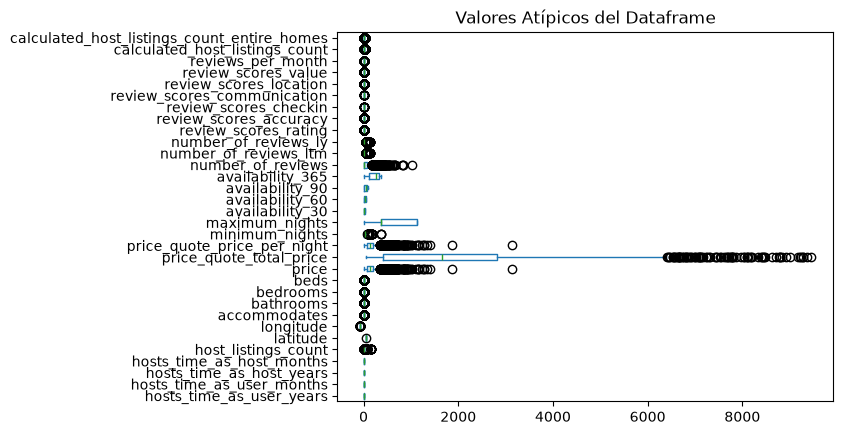

In [10]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize=(20, 15))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

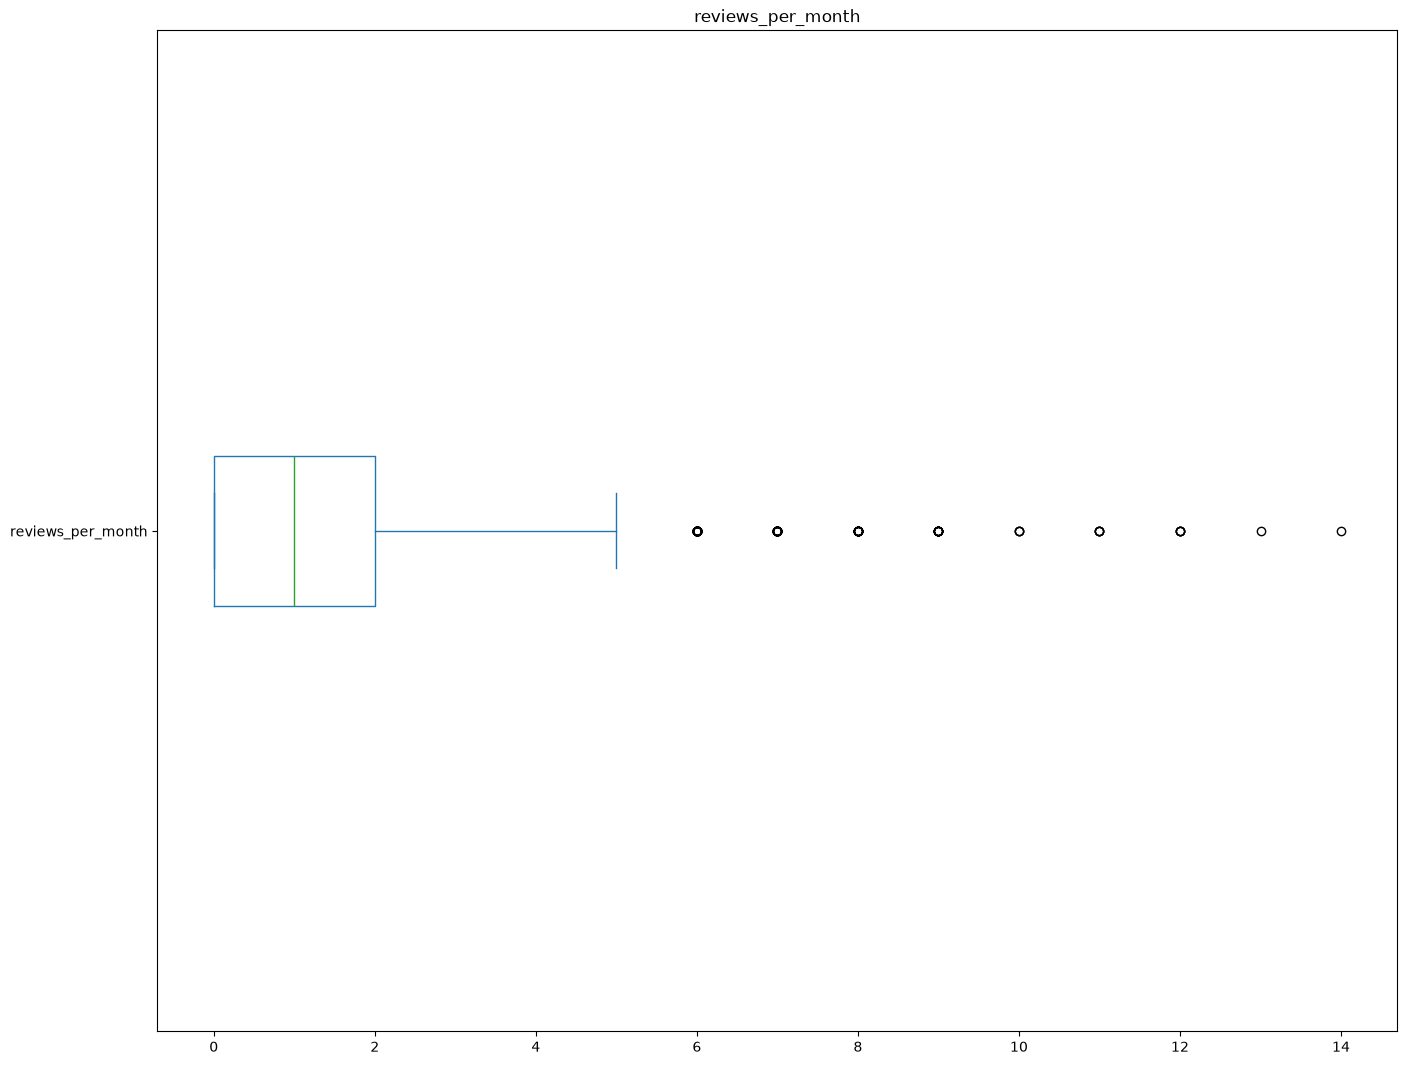

In [11]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(16, 13))
cuantitativas["reviews_per_month"].plot(kind='box', vert=False)
plt.title("reviews_per_month")
plt.show() #dibujamos el diagrama

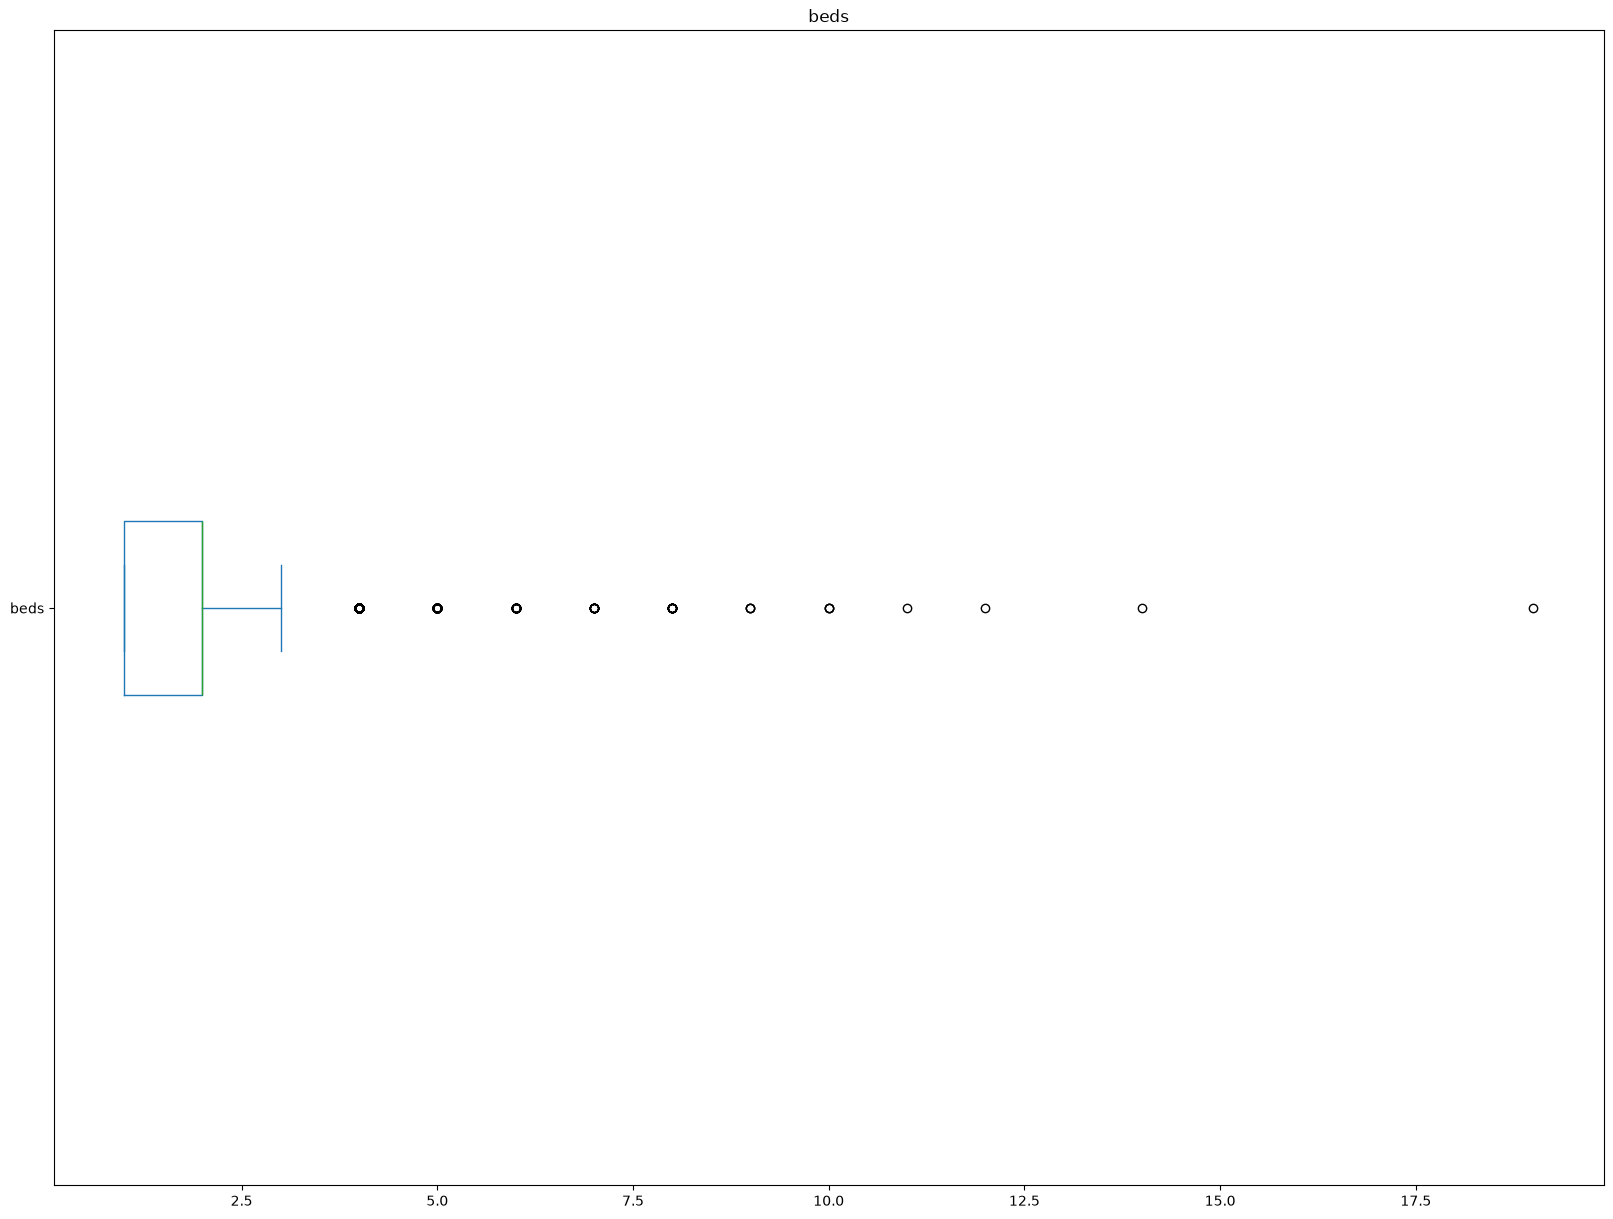

In [12]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(20, 15))
cuantitativas["beds"].plot(kind='box', vert=False)
plt.title("beds")
plt.show() #dibujamos el diagrama

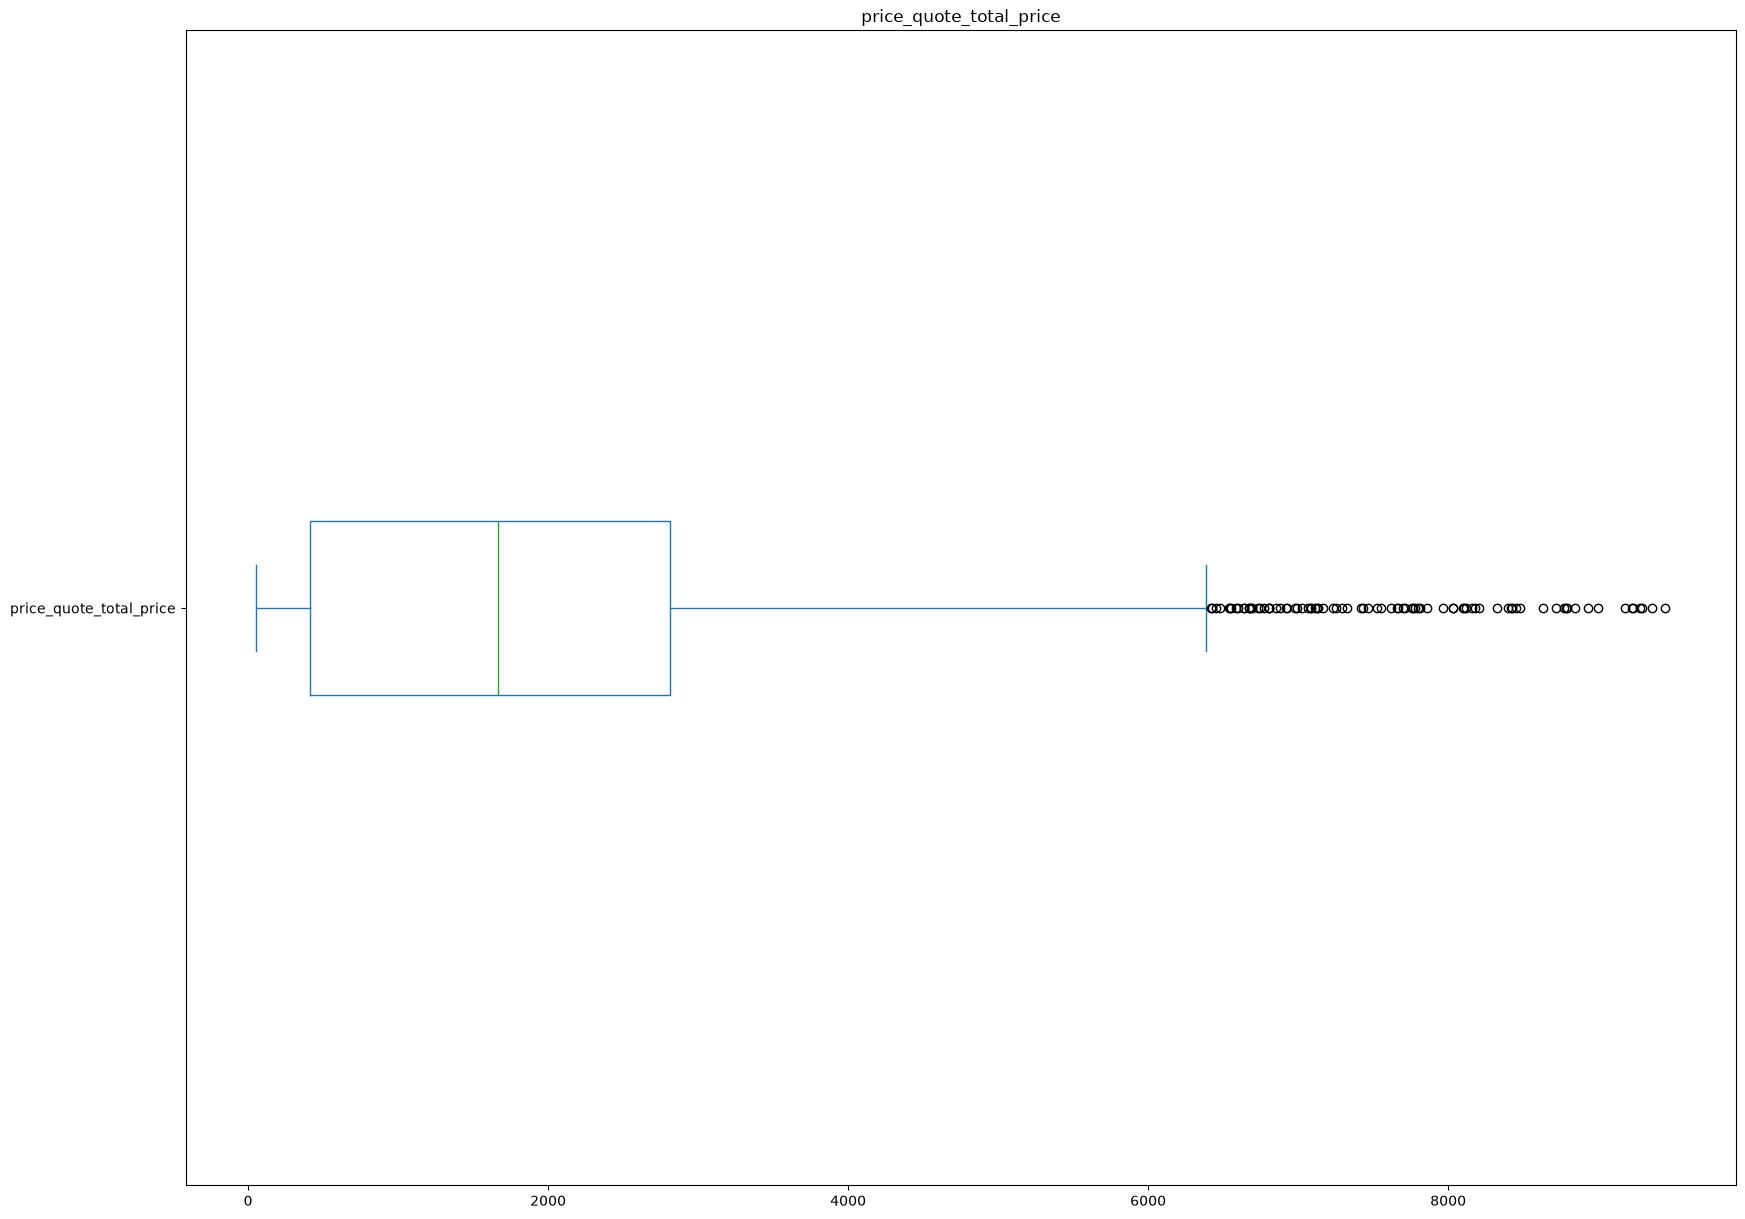

In [13]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(20, 15))
cuantitativas["price_quote_total_price"].plot(kind='box', vert=False)
plt.title("price_quote_total_price")
plt.show() #dibujamos el diagrama

#Modifique los datos para que no se dispararan tanto los valores

In [14]:
minimo = cuantitativas.min()
maximo = cuantitativas.max()

tabla = pd.DataFrame({
    'Minimo': minimo,
    'Maximo': maximo
})

#Neta que flojera verlos en float, mejor que los redondee
tabla.astype(int)

,Minimo,Maximo
hosts_time_as_user_years,0,16
hosts_time_as_user_months,0,11
hosts_time_as_host_years,0,14
hosts_time_as_host_months,0,11
host_listings_count,1,152
latitude,44,45
longitude,-76,-75
accommodates,1,16
bathrooms,0,9
bedrooms,0,10


In [15]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std().astype(int)
Limite_Inferior= y.mean() - 3*y.std().astype(int)
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido hosts_time_as_user_years                         15.883388
hosts_time_as_user_months                        14.769710
hosts_time_as_host_years                         13.548588
hosts_time_as_host_months                        14.576458
host_listings_count                              52.214888
latitude                                         44.999633
longitude                                       -75.017968
accommodates                                      9.397873
bathrooms                                         1.253392
bedrooms                                          5.029336
beds                                              4.992299
price                                           667.953795
price_quote_total_price                        7418.308398
price_quote_price_per_night                     667.946828
minimum_nights                                   85.635130
maximum_nights                                 1778.746975
availability_30               

In [16]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,14.0,7,NaN,7,1.0,NaN,NaN,4.0,NaN,2.0,...,21.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0
1,15.0,3,NaN,6,1.0,NaN,NaN,4.0,NaN,2.0,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0
2,14.0,1,NaN,1,3.0,NaN,NaN,1.0,NaN,2.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0
3,14.0,2,NaN,2,1.0,NaN,NaN,6.0,NaN,5.0,...,15.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0
4,13.0,10,13.0,10,8.0,NaN,NaN,4.0,NaN,2.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2722,8.0,10,2.0,9,1.0,NaN,NaN,6.0,NaN,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
2723,1.0,11,1.0,11,2.0,NaN,NaN,1.0,NaN,1.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0
2724,2.0,1,0.0,0,2.0,NaN,NaN,2.0,NaN,1.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0
2725,1.0,11,1.0,10,1.0,NaN,NaN,6.0,NaN,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0


In [17]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3.isnull().sum()
valores_nulos

hosts_time_as_user_years                          2
hosts_time_as_user_months                         0
hosts_time_as_host_years                         13
hosts_time_as_host_months                         0
host_listings_count                              67
latitude                                       2727
longitude                                      2727
accommodates                                     90
bathrooms                                      2727
bedrooms                                         25
beds                                            145
price                                            54
price_quote_total_price                          45
price_quote_price_per_night                      54
minimum_nights                                   43
maximum_nights                                    0
availability_30                                   0
availability_60                                   0
availability_90                                   0
availability

In [18]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido hosts_time_as_user_years                         19.0
hosts_time_as_user_months                        19.5
hosts_time_as_host_years                         17.0
hosts_time_as_host_months                        19.5
host_listings_count                              11.0
latitude                                         45.0
longitude                                       -75.0
accommodates                                      7.0
bathrooms                                         1.0
bedrooms                                          3.5
beds                                              3.5
price                                           352.5
price_quote_total_price                        6412.5
price_quote_price_per_night                     352.5
minimum_nights                                   73.5
maximum_nights                                 2266.5
availability_30                                  60.0
availability_60                                 123.5
av

In [19]:
# Calculamos Q1
Q1 = cuantitativas.quantile(0.25)

# Calculamos Q3
Q3 = cuantitativas.quantile(0.75)

# Calculamos el IQR
IQR = Q3 - Q1

# Calculamos el límite inferior
Limite_Inferior_iqr = Q1 - 1.5 * IQR

# Calculamos el límite superior
Limite_Superior_iqr = Q3 + 1.5 * IQR

# Obtenemos los datos dentro de los límites
data3_iqr = cuantitativas[
    (cuantitativas <= Limite_Superior_iqr) &
    (cuantitativas >= Limite_Inferior_iqr)
]

# Eliminamos los valores NaN
data3_iqr = data3_iqr.dropna()

# Mostramos el DataFrame limpio
data3_iqr


,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,14,7,14,7,1.0,45.0,-75.0,4.0,1.0,2.0,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
4,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
5,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,5.0,5.0,4.0,4.0,0.0,8.0,4.0
11,13,4,4,5,3.0,45.0,-75.0,1.0,1.0,2.0,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,2.0,0.0
12,6,9,6,9,1.0,45.0,-75.0,5.0,1.0,3.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2714,10,1,9,10,2.0,45.0,-75.0,1.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,0.0
2718,2,1,0,0,2.0,45.0,-75.0,2.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0
2720,3,6,0,6,5.0,45.0,-75.0,2.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,4.0,0.0
2723,1,11,1,11,2.0,45.0,-75.0,1.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0


In [20]:
print(data3_iqr)

      hosts_time_as_user_years  hosts_time_as_user_months  \
0                           14                          7   
4                           13                         10   
5                           13                         10   
11                          13                          4   
12                           6                          9   
...                        ...                        ...   
2714                        10                          1   
2718                         2                          1   
2720                         3                          6   
2723                         1                         11   
2724                         2                          1   

      hosts_time_as_host_years  hosts_time_as_host_months  \
0                           14                          7   
4                           13                         10   
5                           13                         10   
11                     

In [21]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3_iqr.isnull().sum()
valores_nulos

hosts_time_as_user_years                       0
hosts_time_as_user_months                      0
hosts_time_as_host_years                       0
hosts_time_as_host_months                      0
host_listings_count                            0
latitude                                       0
longitude                                      0
accommodates                                   0
bathrooms                                      0
bedrooms                                       0
beds                                           0
price                                          0
price_quote_total_price                        0
price_quote_price_per_night                    0
minimum_nights                                 0
maximum_nights                                 0
availability_30                                0
availability_60                                0
availability_90                                0
availability_365                               0
number_of_reviews   

In [22]:
#Corroboramos valores nulos del dataframe4
valores_nulos=cualitativas.isnull().sum()
valores_nulos

last_scraped                 0
source                       0
name                         0
host_name                    0
host_location                0
host_is_superhost            0
host_identity_verified       0
neighbourhood_cleansed       0
property_type                0
room_type                    0
price_quote_checkin_date     0
price_quote_checkout_date    0
has_availability             0
calendar_last_scraped        0
first_review                 0
last_review                  0
dtype: int64

In [23]:
cualitativas.shape

(2727, 16)

In [24]:
data3_iqr.head(20)

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,14,7,14,7,1.0,45.0,-75.0,4.0,1.0,2.0,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
4,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
5,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,5.0,5.0,4.0,4.0,0.0,8.0,4.0
11,13,4,4,5,3.0,45.0,-75.0,1.0,1.0,2.0,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,2.0,0.0
12,6,9,6,9,1.0,45.0,-75.0,5.0,1.0,3.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
13,13,0,12,8,1.0,45.0,-75.0,4.0,1.0,2.0,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
14,12,7,11,2,1.0,45.0,-75.0,3.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
15,12,5,12,5,3.0,45.0,-75.0,2.0,1.0,1.0,...,5.0,4.0,4.0,4.0,5.0,4.0,4.0,0.0,3.0,3.0
16,13,10,13,10,8.0,45.0,-75.0,2.0,1.0,1.0,...,3.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
19,12,3,12,2,2.0,45.0,-75.0,1.0,1.0,2.0,...,25.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,2.0,0.0


In [25]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data3_iqr], axis=1)
Datos_limpios

,last_scraped,source,name,host_name,host_location,host_is_superhost,host_identity_verified,neighbourhood_cleansed,property_type,room_type,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,24/06/2026,city scrape,Westboro Village Executive Suite,Glenn,"Ottawa, Canada",t,t,Kitchissippi,Entire rental unit,Entire home/apt,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
1,24/06/2026,city scrape,Rural charm close to the city,Daniel,"Ottawa, Canada",t,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24/06/2026,city scrape,Cozy Basement Studio Old Ottawa East,Ela,"Ottawa, Canada",t,t,Capital,Private room in home,Private room,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24/06/2026,city scrape,Up to 3-bdrm with privacy - quiet & safe,William,"Ottawa, Canada",f,t,Gloucester-South Nepean,Entire rental unit,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24/06/2026,city scrape,"Adorable 2 bdrm, Central Ottawa PD1",Greg And Valerie,"Ottawa, Canada",t,t,Kitchissippi,Entire home,Entire home/apt,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2722,24/06/2026,city scrape,Entire 3 Bedroom Home | Park-facing | Private,Rajal,"Ottawa, Canada",f,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2723,24/06/2026,city scrape,Ferngully - A Quiet Room,Shayne,"Ottawa, Canada",f,f,Stittsville-Kanata West,Private room in home,Private room,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
2724,24/06/2026,city scrape,Studio Steps from University of Ottawa-Sandy Hill,OĞUzhan,"Ottawa, Canada",f,t,Rideau-Vanier,Entire home,Entire home/apt,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0
2725,24/06/2026,city scrape,The Town Home in Downtown Ottawa,Andre,"Ottawa, Canada",f,t,Somerset,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
Datos_limpios.shape

(2727, 48)

In [27]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data4_iqr=data3_iqr.copy()
data4_iqr=data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,14,7,14,7,1.0,45.0,-75.0,4.0,1.0,2.0,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
4,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
5,13,10,13,10,8.0,45.0,-75.0,4.0,1.0,2.0,...,2.0,4.0,4.0,5.0,5.0,4.0,4.0,0.0,8.0,4.0
11,13,4,4,5,3.0,45.0,-75.0,1.0,1.0,2.0,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,2.0,0.0
12,6,9,6,9,1.0,45.0,-75.0,5.0,1.0,3.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2714,10,1,9,10,2.0,45.0,-75.0,1.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,0.0
2718,2,1,0,0,2.0,45.0,-75.0,2.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0
2720,3,6,0,6,5.0,45.0,-75.0,2.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,4.0,0.0
2723,1,11,1,11,2.0,45.0,-75.0,1.0,1.0,1.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0


In [28]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data4_iqr.isnull().sum()
valores_nulos

hosts_time_as_user_years                       0
hosts_time_as_user_months                      0
hosts_time_as_host_years                       0
hosts_time_as_host_months                      0
host_listings_count                            0
latitude                                       0
longitude                                      0
accommodates                                   0
bathrooms                                      0
bedrooms                                       0
beds                                           0
price                                          0
price_quote_total_price                        0
price_quote_price_per_night                    0
minimum_nights                                 0
maximum_nights                                 0
availability_30                                0
availability_60                                0
availability_90                                0
availability_365                               0
number_of_reviews   

In [29]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limp = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limp

,last_scraped,source,name,host_name,host_location,host_is_superhost,host_identity_verified,neighbourhood_cleansed,property_type,room_type,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,24/06/2026,city scrape,Westboro Village Executive Suite,Glenn,"Ottawa, Canada",t,t,Kitchissippi,Entire rental unit,Entire home/apt,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
1,24/06/2026,city scrape,Rural charm close to the city,Daniel,"Ottawa, Canada",t,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24/06/2026,city scrape,Cozy Basement Studio Old Ottawa East,Ela,"Ottawa, Canada",t,t,Capital,Private room in home,Private room,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24/06/2026,city scrape,Up to 3-bdrm with privacy - quiet & safe,William,"Ottawa, Canada",f,t,Gloucester-South Nepean,Entire rental unit,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24/06/2026,city scrape,"Adorable 2 bdrm, Central Ottawa PD1",Greg And Valerie,"Ottawa, Canada",t,t,Kitchissippi,Entire home,Entire home/apt,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2722,24/06/2026,city scrape,Entire 3 Bedroom Home | Park-facing | Private,Rajal,"Ottawa, Canada",f,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2723,24/06/2026,city scrape,Ferngully - A Quiet Room,Shayne,"Ottawa, Canada",f,f,Stittsville-Kanata West,Private room in home,Private room,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
2724,24/06/2026,city scrape,Studio Steps from University of Ottawa-Sandy Hill,OĞUzhan,"Ottawa, Canada",f,t,Rideau-Vanier,Entire home,Entire home/apt,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0
2725,24/06/2026,city scrape,The Town Home in Downtown Ottawa,Andre,"Ottawa, Canada",f,t,Somerset,Entire home,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
Ottawa_clean=Datos_limp.copy()
Ottawa_clean=Ottawa_clean.fillna(round(Datos_limp.median(),1))
Ottawa_clean

In [ ]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
Ottawa_clean = Datos_limp.copy()
#Aqui delimitamos que los valores "numericos" (int & float) sean los que se utilicen para la mediana
medianas = Datos_limp.select_dtypes(include="number").median().round(1)
#Ahi ya rellenamos con las medianas que sacamos arriba
Ottawa_clean = Ottawa_clean.fillna(medianas)
#Printeamos el nuevo dt
Ottawa_clean


,last_scraped,source,name,host_name,host_location,host_is_superhost,host_identity_verified,neighbourhood_cleansed,property_type,room_type,...,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes
0,24/06/2026,city scrape,Westboro Village Executive Suite,Glenn,"Ottawa, Canada",t,t,Kitchissippi,Entire rental unit,Entire home/apt,...,21.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,1.0,1.0
1,24/06/2026,city scrape,Rural charm close to the city,Daniel,"Ottawa, Canada",t,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
2,24/06/2026,city scrape,Cozy Basement Studio Old Ottawa East,Ela,"Ottawa, Canada",t,t,Capital,Private room in home,Private room,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
3,24/06/2026,city scrape,Up to 3-bdrm with privacy - quiet & safe,William,"Ottawa, Canada",f,t,Gloucester-South Nepean,Entire rental unit,Entire home/apt,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
4,24/06/2026,city scrape,"Adorable 2 bdrm, Central Ottawa PD1",Greg And Valerie,"Ottawa, Canada",t,t,Kitchissippi,Entire home,Entire home/apt,...,2.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2722,24/06/2026,city scrape,Entire 3 Bedroom Home | Park-facing | Private,Rajal,"Ottawa, Canada",f,t,Rideau-Goulbourn,Entire home,Entire home/apt,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
2723,24/06/2026,city scrape,Ferngully - A Quiet Room,Shayne,"Ottawa, Canada",f,f,Stittsville-Kanata West,Private room in home,Private room,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0
2724,24/06/2026,city scrape,Studio Steps from University of Ottawa-Sandy Hill,OĞUzhan,"Ottawa, Canada",f,t,Rideau-Vanier,Entire home,Entire home/apt,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0
2725,24/06/2026,city scrape,The Town Home in Downtown Ottawa,Andre,"Ottawa, Canada",f,t,Somerset,Entire home,Entire home/apt,...,1.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0


In [33]:
#Corroboramos valores nulos del dataframe4
valores_nulos=Ottawa_clean.isnull().sum()
valores_nulos

last_scraped                                   0
source                                         0
name                                           0
host_name                                      0
host_location                                  0
host_is_superhost                              0
host_identity_verified                         0
neighbourhood_cleansed                         0
property_type                                  0
room_type                                      0
price_quote_checkin_date                       0
price_quote_checkout_date                      0
has_availability                               0
calendar_last_scraped                          0
first_review                                   0
last_review                                    0
hosts_time_as_user_years                       0
hosts_time_as_user_months                      0
hosts_time_as_host_years                       0
hosts_time_as_host_months                      0
host_listings_count 

In [34]:
#Convertir DataFrame a CSV
Ottawa_clean.to_csv("Ottawa_clean_atipico.csv")